In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

True

### Non LLM Workflow

In [48]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    balls_per_boundary: float
    boundary_percent: float
    
    summary: str

In [49]:
def calculate_strike_rate(state: BatsmanState) -> dict:
    runs = state['runs']
    balls = state['balls']

    sr = (runs/balls)*100

    return {'strike_rate':sr}

def calculate_balls_per_boundary(state: BatsmanState) -> dict:
    balls = state['balls']
    fours = state['fours']
    sixes = state['sixes']

    bpb = balls/(fours+sixes)

    return {'balls_per_boundary':bpb}

def calculate_boundary_percent(state: BatsmanState) -> dict:
    runs = state['runs']
    fours = state['fours']
    sixes = state['sixes']

    bp = (((4*fours)+(6*sixes))/runs)*100

    return {'boundary_percent':bp}

def generate_summary(state: BatsmanState) -> dict:
    summary = f'''
    Strike Rate: {state['strike_rate']}
    Balls Per Boundary: {state['balls_per_boundary']}
    Boundary Percent: {state['boundary_percent']}
    '''

    return {'summary':summary}

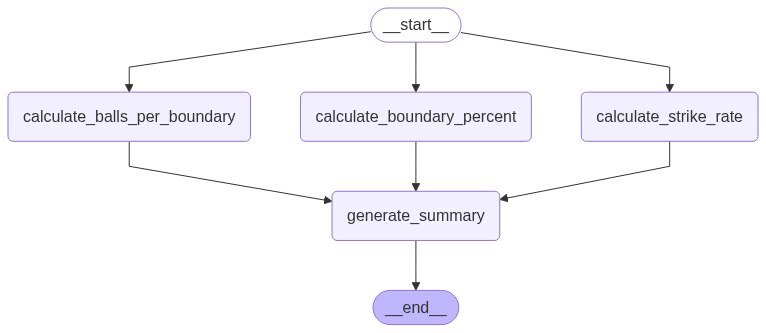

In [50]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_strike_rate',calculate_strike_rate)
graph.add_node('calculate_balls_per_boundary',calculate_balls_per_boundary)
graph.add_node('calculate_boundary_percent',calculate_boundary_percent)
graph.add_node('generate_summary',generate_summary)

graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_balls_per_boundary')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_strike_rate', 'generate_summary')
graph.add_edge('calculate_balls_per_boundary', 'generate_summary')
graph.add_edge('calculate_boundary_percent', 'generate_summary')

graph.add_edge('generate_summary',END)

workflow = graph.compile()
workflow

In [51]:
initial_state = {'runs':100,'balls':50,'fours':6,'sixes':4}
final_state = workflow.invoke(initial_state)
final_state

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'strike_rate': 200.0,
 'balls_per_boundary': 5.0,
 'boundary_percent': 48.0,
 'summary': '\n    Strike Rate: 200.0\n    Balls Per Boundary: 5.0\n    Boundary Percent: 48.0\n    '}

### LLM Workflow

In [68]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
import operator 
from dotenv import load_dotenv

load_dotenv()

True

In [69]:
model = ChatGroq(model="llama3-8b-8192", verbose=True)

In [70]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description='Detailed Feedback for essay')
    score: int = Field(description='Feedback score from 0-10', ge=0, le=10)

In [71]:
structured_model = model.with_structured_output(EvaluationSchema)

In [87]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    final_score: float

In [88]:
def evaluate_language(state: UPSCState):
    prompt = f'Evaluate the quality of essay and provide a feedback and a score from 0 to 10 \n{state['essay']}'
    output = structured_model.invoke(prompt)

    return {'language_feedback':output.feedback, 'individual_scores':[output.score]}

def evaluate_analysis(state: UPSCState):
    prompt = f'Evaluate the depth of analysis of essay and provide a feedback and a score from 0 to 10 \n{state['essay']}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback':output.feedback, 'individual_scores':[output.score]}

def evaluate_clarity(state: UPSCState):
    prompt = f'Evaluate the clarity of thought of essay and provide a feedback and a score from 0 to 10 \n{state['essay']}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback':output.feedback, 'individual_scores':[output.score]}

def evaluate_overall(state: UPSCState):
    prompt = f'Based on the following feedback create a summarized feedback \nLanguage Feedback: {state['language_feedback']}\nAnalysis Feedback: {state['analysis_feedback']}\nClarity Feedback: {state['clarity_feedback']}'
    output = model.invoke(prompt).content

    score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback':output, 'final_score':score}

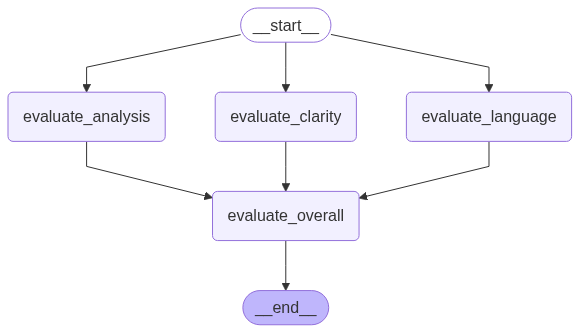

In [89]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('evaluate_clarity',evaluate_clarity)
graph.add_node('evaluate_overall',evaluate_overall)

graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluate_clarity')

graph.add_edge('evaluate_language','evaluate_overall')
graph.add_edge('evaluate_analysis','evaluate_overall')
graph.add_edge('evaluate_clarity','evaluate_overall')

graph.add_edge('evaluate_overall',END)

workflow = graph.compile()
workflow

In [90]:
initial_state = {'essay':'''In a world defined by specialization and purpose, the word "anything" stands as a curious anomaly—a void of limitless possibility that, paradoxically, can be its own undoing. While we are often taught to embrace "anything is possible," this seemingly liberating concept can be a source of profound paralysis. When the canvas is truly blank, and the subject is without limits, the very act of choosing becomes an insurmountable challenge. The tyranny of anything is not born of constraint but of a total lack of it.

For a writer staring at a blank page, the instruction to "write about anything" is often more terrifying than a specific, difficult prompt. The mind, unguided, spirals into a chaos of competing ideas. Should it be a poignant short story, a sharp critique of modern society, or a whimsical poem? Each path is valid, yet none feels definitive. This is the heart of the dilemma: without a framework, without a specific problem to solve, action loses its purpose. The potential of "anything" makes every single choice feel small and inadequate.

This phenomenon extends far beyond the creative process. In our personal lives, the age of infinite choices presents a similar struggle. We can be anything we want, pursue any career, live in any city, and learn any skill. This freedom, while a hallmark of progress, often leads to indecision and anxiety. We fear making the "wrong" choice, so we make no choice at all, perpetually suspended in a state of uncommitted potential. We become a jack of all trades and a master of none, or worse, a master of nothing.

The solution to this modern-day paradox lies not in wishing for less freedom, but in imposing a personal, voluntary constraint. We find purpose and direction not by embracing "anything" but by deliberately and consciously choosing something. A theme, a goal, or a single question to answer. By narrowing the focus, we move from the overwhelming to the manageable. We give our efforts meaning and our actions a clear trajectory. The power of a deliberate choice, no matter how small, is that it transforms a boundless void into a purposeful path.

Ultimately, "anything" is a starting point, not a destination. It is the raw material that must be shaped by a specific vision. The true art of living and creating is not in having endless options but in the discipline of selecting one and seeing it through. It is through this act of intentional choice that we find clarity, overcome paralysis, and turn the vast, chaotic expanse of "anything" into a meaningful "something."'''}
final_state = workflow.invoke(initial_state)
final_state

{'essay': 'In a world defined by specialization and purpose, the word "anything" stands as a curious anomaly—a void of limitless possibility that, paradoxically, can be its own undoing. While we are often taught to embrace "anything is possible," this seemingly liberating concept can be a source of profound paralysis. When the canvas is truly blank, and the subject is without limits, the very act of choosing becomes an insurmountable challenge. The tyranny of anything is not born of constraint but of a total lack of it.\n\nFor a writer staring at a blank page, the instruction to "write about anything" is often more terrifying than a specific, difficult prompt. The mind, unguided, spirals into a chaos of competing ideas. Should it be a poignant short story, a sharp critique of modern society, or a whimsical poem? Each path is valid, yet none feels definitive. This is the heart of the dilemma: without a framework, without a specific problem to solve, action loses its purpose. The potenti

In [92]:
initial_state = {'essay':'''The world is full of anything, but anything is not good. Sometimes anything is not good. My English is bad, so this essay is bad. The topic is anything, so it can be bad. I like bad essays and bad English. Is my English bad? Yes, it is very very bad.

People say, "you can be anything." This is a lie. You cannot be anything. You cannot be a chair, you cannot be a dog, you cannot be a banana. This is not true. It is a big lie. People are lying to you. Don't believe them. You cannot be anything.

In life, you have many choices. Like which food to eat. Which clothes to wear. These are choices. But the choices are not anything. They are some things. Like food and clothes. So "anything" is not real. It is a big fake word.

The end of the essay is here. I am done writing the bad essay on anything. It is very bad, like I promised. I hope you like it. I like it. It is good because it is bad.'''}
final_state = workflow.invoke(initial_state)
final_state

{'essay': 'The world is full of anything, but anything is not good. Sometimes anything is not good. My English is bad, so this essay is bad. The topic is anything, so it can be bad. I like bad essays and bad English. Is my English bad? Yes, it is very very bad.\n\nPeople say, "you can be anything." This is a lie. You cannot be anything. You cannot be a chair, you cannot be a dog, you cannot be a banana. This is not true. It is a big lie. People are lying to you. Don\'t believe them. You cannot be anything.\n\nIn life, you have many choices. Like which food to eat. Which clothes to wear. These are choices. But the choices are not anything. They are some things. Like food and clothes. So "anything" is not real. It is a big fake word.\n\nThe end of the essay is here. I am done writing the bad essay on anything. It is very bad, like I promised. I hope you like it. I like it. It is good because it is bad.',
 'language_feedback': "The essay lacks coherence and clarity, with many grammatical 